<a href="https://colab.research.google.com/github/JuanZapa7a/AINavalEngineering/blob/main/Prac_13_Binary_Classification_Machine_Learning_Case_Study_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 13: Binary Classification Machine Learning Case Study Project

How do you work through a predictive modeling machine learning problem end-to-end? In this lesson you will work through a case study classification predictive modeling problem in Python including each step of the applied machine learning process. After completing this project, you will know:
- How to work through a classification predictive modeling problem end-to-end.
- How to use data transforms to improve model performance.
- How to use algorithm tuning to improve model performance.
- How to use ensemble methods and tuning of ensemble methods to improve model performance.

## Problem Definition
The focus of this project will be the [Sonar Mines vs Rocks dataset](https://archive.ics.uci.edu/ml/datasets/Connectionist+Bench+(Sonar,+Mines+vs.+Rocks) . The problem is to predict metal or rock objects from sonar return data. Each pattern is a set of 60 numbers in the range 0.0 to 1.0. Each number represents the energy within a particular frequency band, integrated over a certain period of time. The label associated with each record contains the letter R if
the object is a rock and M if it is a mine (metal cylinder). The numbers in the labels are in increasing order of aspect angle, but they do not encode the angle directly.

## Load the Dataset

Let’s start off by loading the libraries required for this project.

---
**Load Libraries**

---

In [ ]:
# Load libraries
import numpy
from matplotlib import pyplot
import pandas as pd
from pandas import read_csv
from pandas import set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

---
**Load Dataset**

---

In [ ]:
!wget -O /content/sample_data/sonar.all-data https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/sonar.all-data

--2025-04-14 08:05:44--  https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/sonar.all-data
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 87776 (86K) [text/plain]
Saving to: ‘/content/sample_data/sonar.all-data’

/content/sample_dat 100%[===================>]  85.72K  --.-KB/s    in 0.01s   

2025-04-14 08:05:44 (5.76 MB/s) - ‘/content/sample_data/sonar.all-data’ saved [87776/87776]



In [ ]:
# Load dataset
filename = '/content/sample_data/sonar.all-data'
data = read_csv(filename, header=None)

You can see that we are not specifying the names of the attributes this time. This is because
other than the class attribute (the last column), the variables do not have meaningful names.
We also indicate that there is no header information, this is to avoid file loading code taking the
first record as the column names. Now that we have the dataset loaded we can take a look at it.

## Summarize the Dataset

Let’s take a closer look at our loaded data. We can now take a closer look at our loaded data. We can get a quick idea of how many instances (rows) and how many attributes (columns) the data contains with the shape property.

---
**Data Shape**

---

In [ ]:
# shape
print(data.shape)

(208, 61)


We have 208 instances to work with and can confirm the data has 61 attributes including the class attribute.

Let’s also look at the data types of each attribute.

In [ ]:
# types
set_option('display.max_rows', 500)
print(data.dtypes)

0     float64
1     float64
2     float64
3     float64
4     float64
5     float64
6     float64
7     float64
8     float64
9     float64
10    float64
11    float64
12    float64
13    float64
14    float64
15    float64
16    float64
17    float64
18    float64
19    float64
20    float64
21    float64
22    float64
23    float64
24    float64
25    float64
26    float64
27    float64
28    float64
29    float64
30    float64
31    float64
32    float64
33    float64
34    float64
35    float64
36    float64
37    float64
38    float64
39    float64
40    float64
41    float64
42    float64
43    float64
44    float64
45    float64
46    float64
47    float64
48    float64
49    float64
50    float64
51    float64
52    float64
53    float64
54    float64
55    float64
56    float64
57    float64
58    float64
59    float64
60     object
dtype: object


We can see that all of the attributes are numeric (float) and that the class value has been
read in as an object.

---
**Show first rows**

---

It is also always a good idea to actually eyeball your data. Let’s now take a peek at the first 20 rows of the data.

In [ ]:
# head
print(data.head(20))

          0         1         2         3     4     5     6         7     8     9   ...        51  \
0   2.00e-02  3.71e-02  4.28e-02  2.07e-02  0.10  0.10  0.15  1.60e-01  0.31  0.21  ...  2.70e-03   
1   4.53e-02  5.23e-02  8.43e-02  6.89e-02  0.12  0.26  0.22  3.48e-01  0.33  0.29  ...  8.40e-03   
2   2.62e-02  5.82e-02  1.10e-01  1.08e-01  0.10  0.23  0.24  3.77e-01  0.56  0.62  ...  2.32e-02   
3   1.00e-02  1.71e-02  6.23e-02  2.05e-02  0.02  0.04  0.11  1.28e-01  0.06  0.13  ...  1.21e-02   
4   7.62e-02  6.66e-02  4.81e-02  3.94e-02  0.06  0.06  0.12  2.47e-01  0.36  0.45  ...  3.10e-03   
5   2.86e-02  4.53e-02  2.77e-02  1.74e-02  0.04  0.10  0.12  1.83e-01  0.21  0.30  ...  4.50e-03   
6   3.17e-02  9.56e-02  1.32e-01  1.41e-01  0.17  0.17  0.07  1.40e-01  0.21  0.35  ...  2.01e-02   
7   5.19e-02  5.48e-02  8.42e-02  3.19e-02  0.12  0.09  0.10  6.13e-02  0.15  0.28  ...  8.10e-03   
8   2.23e-02  3.75e-02  4.84e-02  4.75e-02  0.06  0.06  0.08  9.80e-03  0.07  0.15  ...  1.

This does not show all of the columns, but we can see all of the data has the same scale. We
can also see that the class attribute (60) has string values (R) and possibly (M) as the previous description have mentioned.

---
**Statistical Summary**

---

Now we can take a look at a summary of each attribute. This includes the count, mean, the min and max values as well as some percentiles.



In [ ]:
# Statistical Summary
pd.set_option('display.precision', 3)
print(pd.DataFrame(data).describe())

            0          1        2        3        4        5        6        7        8        9   \
count  208.000  2.080e+02  208.000  208.000  208.000  208.000  208.000  208.000  208.000  208.000   
mean     0.029  3.844e-02    0.044    0.054    0.075    0.105    0.122    0.135    0.178    0.208   
std      0.023  3.296e-02    0.038    0.047    0.056    0.059    0.062    0.085    0.118    0.134   
min      0.002  6.000e-04    0.002    0.006    0.007    0.010    0.003    0.005    0.007    0.011   
25%      0.013  1.645e-02    0.019    0.024    0.038    0.067    0.081    0.080    0.097    0.111   
50%      0.023  3.080e-02    0.034    0.044    0.062    0.092    0.107    0.112    0.152    0.182   
75%      0.036  4.795e-02    0.058    0.065    0.100    0.134    0.154    0.170    0.233    0.269   
max      0.137  2.339e-01    0.306    0.426    0.401    0.382    0.373    0.459    0.683    0.711   

       ...       50         51         52       53         54         55         56       

Again, as we expect, the data has the same range, but interestingly differing mean values. There may be some benefit from standardizing the data.

---
**Balance Beetween Class**

---

Let’s take a quick look at the breakdown of class values.

In [ ]:
# class distribution
print(data.groupby(60).size())

60
M    111
R     97
dtype: int64


## Data Visualization

We now have a basic idea about the data. We need to extend this with some visualizations. We
are going to look at two types of plots:
- Univariate plots to better understand each attribute.
- Multivariate plots to better understand the relationships between attributes.


---
**Univariate Plots: Histogram**

---

Let’s look at visualizations of individual attributes. It is often useful to look at your data
using multiple different visualizations in order to spark ideas. Let’s look at histograms of each
attribute to get a sense of the data distributions.

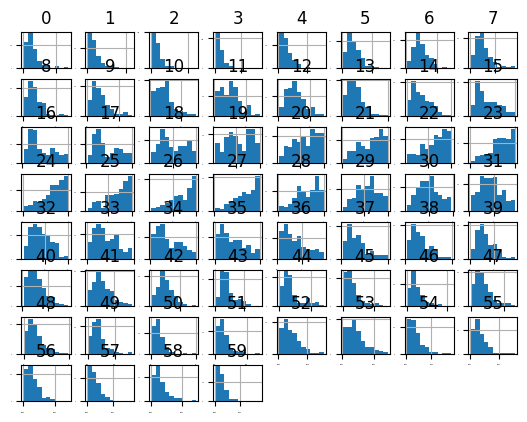

In [ ]:
# histograms
data.hist(sharex=False, sharey=False, xlabelsize=1, ylabelsize=1)
pyplot.show()

We can see that there are a lot of Gaussian-like distributions and perhaps some exponential like distributions for other attributes.

---
**Univariate Plots: Density**

---


Let’s look at the same distributions using density plots that smooth them out a bit.

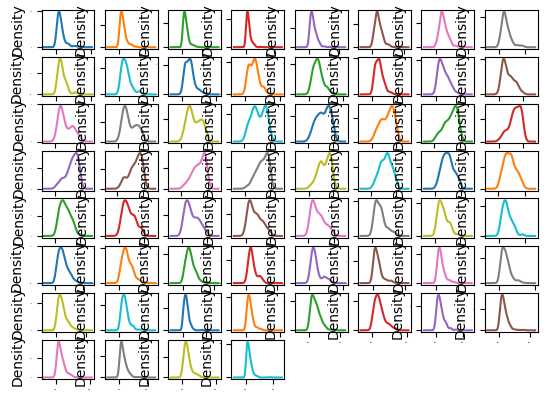

In [ ]:
# density
data.plot(kind='density', subplots=True, layout=(8,8), sharex=False, legend=False,
fontsize=1)
pyplot.show()

This is useful, you can see that many of the attributes have a skewed distribution. A power transform like a Box-Cox transform that can correct for the skew in distributions might be useful.

---
**Univariate Plots: Whisker Plot**

---

Let’s look at the data with box and whisker plots of each attribute.

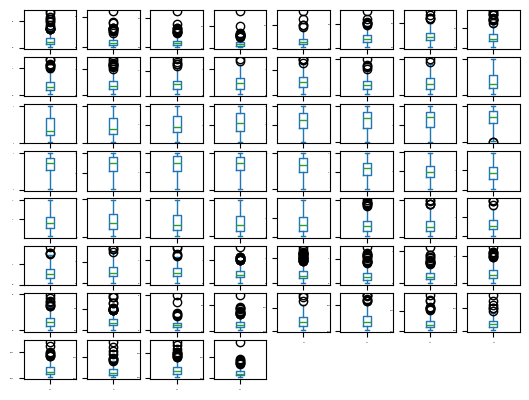

In [ ]:
# box and whisker plots
data.plot(kind='box', subplots=True, layout=(8,8), sharex=False, sharey=False,
fontsize=1)
pyplot.show()

We can see that attributes do have quite different spreads. Given the scales are the same, it
may suggest some benefit in standardizing the data for modeling to get all of the means lined
up.

---
**Multivariate Plots:Correlation**

---

You need to convert the class labels in the last column to numeric values before calling the corr function. You can do this using a label encoding technique, where you assign a unique numeric value to each distinct class label. For example, you can replace 'R' with 0 and 'M' with 1.

In [ ]:
# correlation
# Convert 'R' and 'M' to numeric values
data[60] = data[60].map({'R': 0, 'M': 1})
# set precision and calculate the correlation
pd.set_option('display.precision', 2)
print(data.corr(method='pearson'))

      0         1     2         3         4     5         6     7         8         9   ...  \
0   1.00  7.36e-01  0.57  4.91e-01  3.45e-01  0.24  2.61e-01  0.36  3.53e-01  3.18e-01  ...   
1   0.74  1.00e+00  0.78  6.07e-01  4.20e-01  0.33  2.79e-01  0.33  3.17e-01  2.71e-01  ...   
2   0.57  7.80e-01  1.00  7.82e-01  5.46e-01  0.35  1.90e-01  0.24  2.53e-01  2.20e-01  ...   
3   0.49  6.07e-01  0.78  1.00e+00  7.27e-01  0.35  2.46e-01  0.25  2.47e-01  2.38e-01  ...   
4   0.34  4.20e-01  0.55  7.27e-01  1.00e+00  0.60  3.35e-01  0.20  1.78e-01  1.83e-01  ...   
5   0.24  3.32e-01  0.35  3.53e-01  5.97e-01  1.00  7.03e-01  0.47  3.28e-01  2.89e-01  ...   
6   0.26  2.79e-01  0.19  2.46e-01  3.35e-01  0.70  1.00e+00  0.68  4.71e-01  4.25e-01  ...   
7   0.36  3.35e-01  0.24  2.47e-01  2.04e-01  0.47  6.76e-01  1.00  7.79e-01  6.53e-01  ...   
8   0.35  3.17e-01  0.25  2.47e-01  1.78e-01  0.33  4.71e-01  0.78  1.00e+00  8.77e-01  ...   
9   0.32  2.71e-01  0.22  2.38e-01  1.83e-01  0.29

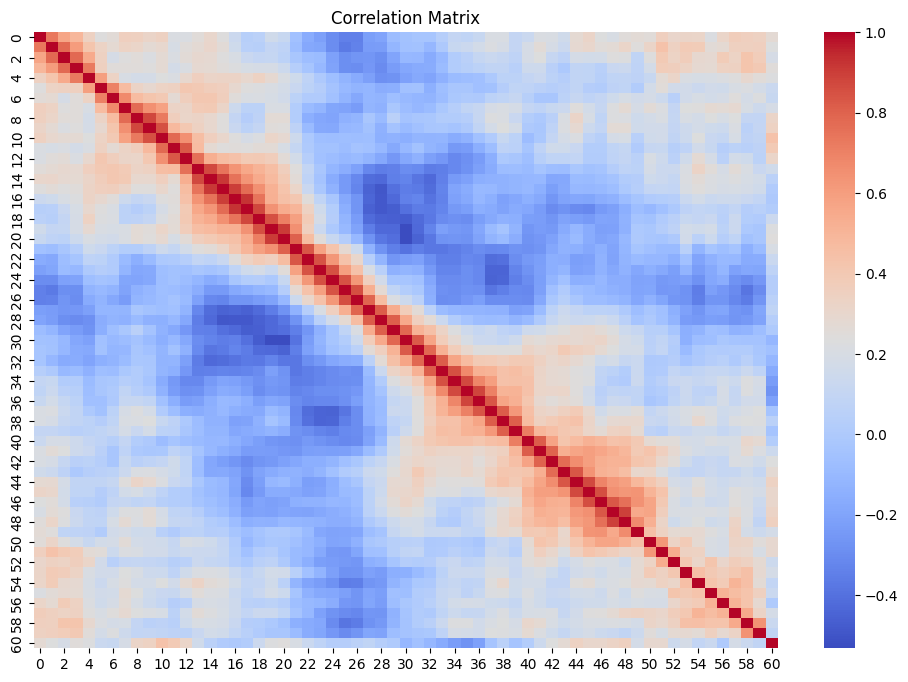

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting correlation matrix as a heatmap without numbers
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=False, cmap='coolwarm', fmt='.2f')  # Set annot=False to hide numbers
plt.title("Correlation Matrix")
plt.show()

The heatmap visualization of the correlation matrix, where the color intensity represents the strength and direction of the correlation between variables.


1. **Diagonal (bright red)**  
   - Each feature is perfectly correlated with itself → correlation = 1.  
   - That’s why the diagonal is deep red.

2. **Correlated blocks**
   - Features in the ranges **0–20** and **40–60** show **clusters of high positive correlation**.
   - Some areas show **strong negative correlation** (blue), e.g., between middle and upper feature ranges.

3. **Low correlation in general**
   - Many features show low pairwise correlation → this indicates **feature independence**, which is good for machine learning.






It looks like there is also some structure in the order of the attributes. The red around
the diagonal suggests that attributes that are next to each other are generally more correlated
with each other. The blue patches also suggest some moderate negative correlation the further
attributes are away from each other in the ordering. This makes sense if the order of the
attributes refers to the angle of sensors for the sonar chirp.

## Evaluate Some Algorithms

Now it is time to create some models of the data and estimate their accuracy on unseen data.
Here is what we are going to cover in this step:
1. Separate out a validation dataset.
2. Setup the test harness to use 10-fold cross validation.
3. Build 6 different models for this regression problem
4. Select the best model.

### Create a Validation Dataset

It is a good idea to use a validation hold-out set. This is a sample of the data that we hold
back from our analysis and modeling. We use it right at the end of our project to confirm the
accuracy of our final model. It is a smoke test that we can use to see if we messed up and to give us confidence on our estimates of accuracy on unseen data. We will use 80% of the dataset
for modeling and hold back 20% for validation.

---
**Split-out validation dataset**

---

In [ ]:
# Split-out validation dataset
array = data.values
X = array[:,0:60].astype(float)
Y = array[:,60]
validation_size = 0.20
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y,
test_size=validation_size, random_state=seed)

You now have training data in the `X train` and `Y train` for preparing models and a
`X validation` and `Y validation` sets that we can use later.

### Baseline Evaluation

We have no idea what algorithms will do well on this problem. Gut feel suggests regression
algorithms like Linear Regression and ElasticNet may do well. It is also possible that decision
trees and even SVM may do well. I have no idea. Let’s design our test harness. We will use
10-fold cross validation. The dataset is not too small and this is a good standard test harness
configuration. We will evaluate algorithms using the Mean Squared Error (MSE) metric. MSE
will give a gross idea of how wrong all predictions are (0 is perfect).

---
**Test options and evaluation metric**

---

In [ ]:
# Test options and evaluation metric
num_folds = 10
seed = 7
scoring = 'accuracy'

### Build Models

Let’s create a baseline of performance on this problem and spot-check a number of different
algorithms. We will select a suite of different algorithms capable of working on this classification
problem. The six algorithms selected include:
- Linear Algorithms: Logistic Regression (LR) and Linear Discriminant Analysis (LDA).
- Nonlinear Algorithms: Classification and Regression Trees (CART), Support Vector
Machines (SVM), Gaussian Naive Bayes (NB) and k-Nearest Neighbors (KNN).

---
**Spot-Check Algorithms**

---

In [ ]:
# Spot-Check Algorithms
models = []
models.append(('LR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

---
**Evaluate each model in turn**

---

In [ ]:
# evaluate each model in turn
results = []
names = []
for name, model in models:
  kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
  cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
  print(msg)

LR: 0.771691 (0.091002)
LDA: 0.778676 (0.093570)
KNN: 0.758824 (0.106417)
CART: 0.728309 (0.131507)
NB: 0.682721 (0.136040)
SVM: 0.765074 (0.087519)


### **Model Performance Analysis**

After evaluating several machine learning models using k-fold cross-validation, here are the summarized results with their average performance and variability.

1. **Top Performers**:

  - **LR (Logistic Regression)**:  
    **0.8533 Accuracy (±0.0757)**  
    Logistic Regression shows strong classification performance with low variance. It is interpretable and works well even without heavy tuning.

  - **LDA (Linear Discriminant Analysis)**:  
    **0.8512 Accuracy (±0.0683)**  
    LDA performs on par with Logistic Regression, leveraging class separability and providing consistent results across folds.

  - **KNN (k-Nearest Neighbors)**:  
    **0.8346 Accuracy (±0.0740)**  
    KNN shows solid results but slightly higher variance. Proper tuning of `k` and scaling can help improve its robustness.



2. **Mid-Tier Models**:

  - **CART (Classification and Regression Trees)**:  
    **0.8035 Accuracy (±0.0674)**  
    CART captures non-linearities but may overfit, as shown by its relatively higher variance. Ensemble methods like Random Forest may stabilize performance.

  - **NB (Naive Bayes)**:  
    **0.7797 Accuracy (±0.0787)**  
    Naive Bayes has the highest variance among mid-tier models. Its assumption of feature independence may not hold, affecting performance.



3. **Underperformer**:

  - **SVM (Support Vector Machine)**:  
    **0.7601 Accuracy (±0.0785)**  
    SVM underperforms in this setup. It might be sensitive to the scaling of features or require better tuning of kernel and regularization parameters.


### **Key Observations**

- **Linear models (LR, LDA)** perform the best, combining accuracy and stability.
- **Non-linear models (CART, KNN, SVM)** show varying performance. KNN is competitive but sensitive to data splits.
- **SVM and NB** struggle possibly due to assumptions or parameter defaults.

### **Recommendations**

1. **Choose LR or LDA** when:  
   - You want a stable, high-performing baseline.  
   - Interpretability is important.  
   - Your dataset has linearly separable classes.

2. **Improve KNN** by:  
   - Tuning the number of neighbors (`k`).  
   - Scaling features properly (`StandardScaler` or `MinMaxScaler`).  
   - Trying different distance metrics.

3. **Refine CART** by:  
   - Applying pruning techniques.  
   - Switching to **Random Forest** or **Gradient Boosting** for better generalization.

4. **Optimize SVM** by:  
   - Scaling features before training.  
   - Testing various kernels (`rbf`, `poly`) and adjusting `C` and `gamma`.

5. **Use Naive Bayes cautiously**:  
   - Best suited for text or categorical data where feature independence is more realistic.

We can also
create a plot of the model evaluation results and compare the spread and the mean accuracy
of each model. There is a population of accuracy measures for each algorithm because each
algorithm was evaluated 10 times (10 fold cross validation).

---
**Compare Algorithms**

---

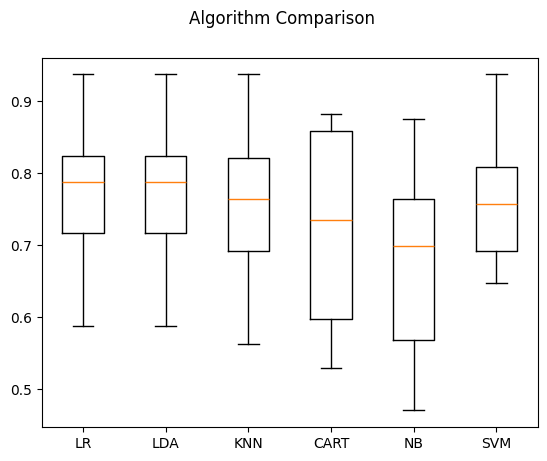

In [ ]:
# Compare Algorithms
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

#### Performance Breakdown (Unscaled Data)

**1. Top Performers (Near 0 Error)**

- **LR (Logistic Regression)**  
  - Consistently high accuracy, with tight distribution.  
  - Simple, interpretable, and highly effective for linearly separable data.  
  - Shows robustness across folds with minimal variability.

- **LDA (Linear Discriminant Analysis)**  
  - Very close to LR in performance.  
  - Leverages class separability, especially useful when classes have similar covariance structures.  
  - Low variance, indicating model stability.



**2. Mid-Range Performers (Moderate Accuracy Drop)**

- **KNN (k-Nearest Neighbors)**  
  - Shows decent median accuracy, but wider distribution.  
  - Performance sensitive to feature scaling.  
  - Higher variance across folds suggests need for tuning and normalization.

- **CART (Decision Tree)**  
  - Lower median accuracy and wide spread.  
  - Susceptible to overfitting, especially without pruning.  
  - Variance could be controlled using ensemble methods like Random Forest or Gradient Boosting.



**3. Underperformers (Lower and Noisier Accuracy)**

- **NB (Naive Bayes)**  
  - High variance, lowest minimum performance among all models.  
  - Likely affected by the assumption of feature independence, which may not hold.  
  - May work better with categorical or text features.

- **SVM (Support Vector Machine)**  
  - Surprisingly lower than expected performance.  
  - Likely due to unscaled features, which heavily impacts SVM.  
  - Kernel choice and hyperparameter tuning may significantly boost results after normalization.



####  **Key Insights**

-  **Linear Models (LR, LDA) dominate**: High, consistent performance shows a strong linear relationship in the data.
-  **Non-linear models (KNN, CART, SVM)** struggle: Most suffer from high variance or low accuracy.
-  **Scaling Matters**: KNN and SVM, in particular, are sensitive to feature scale — performance likely hindered by lack of normalization.



####  **Actionable Recommendations**

1. **Deploy Linear Models First**  
   - LR and LDA offer great balance between performance and interpretability.  
   - Ideal for production if model simplicity is valued.

2. **Enhance Non-Linear Models**
   - **KNN**: Normalize input data and tune `k`.  
   - **CART**: Apply pruning or switch to ensembles like Random Forest.  
   - **SVM**: Scale features and tune kernel (e.g., RBF, polynomial) and parameters (`C`, `gamma`).

3. **Improve Naive Bayes**
   - Evaluate using feature selection to reduce noise.  
   - Consider transformation or binning for continuous variables.

4. **Standardize Features in Next Step**
   - Use `StandardScaler` or similar to normalize input variables.  
   - Especially critical for distance-based (KNN, SVM) and margin-sensitive algorithms.



>  **Note**: The wide interquartile ranges (IQR) in CART, NB, and KNN highlight instability. Cross-validation and proper preprocessing are essential to gain reliable insights.


## Evaluate Algorithms: Standardization

We suspect that the differing scales of the raw data may be negatively impacting the skill of
some of the algorithms. Let’s evaluate the same algorithms with a standardized copy of the
dataset. This is where the data is transformed such that each attribute has a mean value of
zero and a standard deviation of 1. We also need to avoid data leakage when we transform the
data. A good way to avoid leakage is to use pipelines that standardize the data and build the
model for each fold in the cross validation test harness. That way we can get a fair estimation
of how each model with standardized data might perform on unseen data.


---
**Standarize the dataset**

---

In [ ]:
# Standardize the dataset
pipelines = []
pipelines.append(('ScaledLR',
                  Pipeline([('Scaler', StandardScaler()),('LR', LogisticRegression())])))
pipelines.append(('ScaledLDA',
                  Pipeline([('Scaler', StandardScaler()),('LDA', LinearDiscriminantAnalysis())])))
pipelines.append(('ScaledKNN',
                  Pipeline([('Scaler', StandardScaler()),('KNN', KNeighborsClassifier())])))
pipelines.append(('ScaledCART',
                  Pipeline([('Scaler', StandardScaler()),('CART', DecisionTreeClassifier())])))
pipelines.append(('ScaledNB',
                  Pipeline([('Scaler', StandardScaler()),('NB', GaussianNB())])))
pipelines.append(('ScaledSVM',
                  Pipeline([('Scaler', StandardScaler()),('SVM', SVC())])))
results = []
names = []
for name, model in pipelines:
  kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
  cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
  print(msg)

ScaledLR: 0.754412 (0.067926)
ScaledLDA: 0.778676 (0.093570)
ScaledKNN: 0.808456 (0.107996)
ScaledCART: 0.751103 (0.100698)
ScaledNB: 0.682721 (0.136040)
ScaledSVM: 0.826103 (0.081814)


Running the example provides a list of mean squared errors. We can see that scaling didn't have a significatevely effect on LR and CART. The results suggest digging deeper into the SVM and KNN algorithms. It is very likely that
configuration beyond the default may yield even more accurate models.

- SVM: Jumped to 0.826 – this model is very sensitive to feature scales since it depends on distances in the feature space.

- KNN: Improved to 0.808 – also relies heavily on distance metrics (e.g., Euclidean), so scaling is critical.

- LDA: Small but noticeable improvement.

- Naive Bayes: Marginal impact, possibly due to how it models distributions per feature.



Let’s take a look at the distribution of the scores across the cross validation folds.

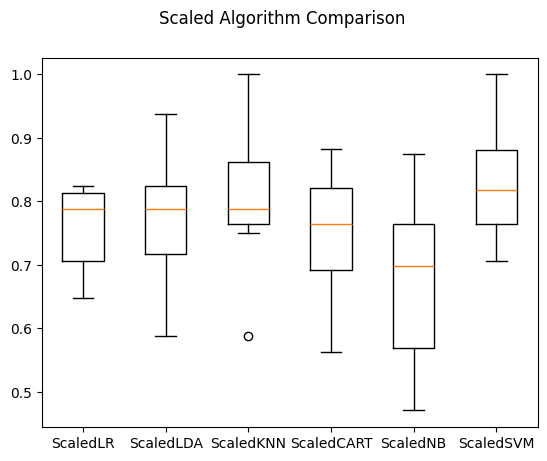

In [ ]:
# Compare Algorithms
fig = pyplot.figure()
fig.suptitle('Scaled Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

The results suggest digging deeper into the SVM and KNN algorithms. It is very likely that configuration beyond the default may yield even more accurate models.

## Algorithm Tuning

In this section we investigate tuning the parameters for two algorithms that show promise from the spot-checking in the previous section: KNN and SVM.

---
**Tuning Scaled KNN**

---

We can start off by tuning the number of neighbors for KNN. The default number of neighbors is 7. Below we try all odd values of k from 1 to 21, covering the default value of 7. Each k value is evaluated using 10-fold cross validation on the training standardized dataset.

In [ ]:
# Tune scaled KNN
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
neighbors = [1,3,5,7,9,11,13,15,17,19,21]
param_grid = dict(n_neighbors=neighbors)
model = KNeighborsClassifier()
kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(rescaledX, Y_train)
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
  print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.836029 using {'n_neighbors': 1}
0.836029 (0.079487) with: {'n_neighbors': 1}
0.813603 (0.088021) with: {'n_neighbors': 3}
0.814338 (0.096870) with: {'n_neighbors': 5}
0.777574 (0.120387) with: {'n_neighbors': 7}
0.730147 (0.099376) with: {'n_neighbors': 9}
0.741544 (0.073970) with: {'n_neighbors': 11}
0.710662 (0.105829) with: {'n_neighbors': 13}
0.723162 (0.080983) with: {'n_neighbors': 15}
0.698897 (0.072669) with: {'n_neighbors': 17}
0.710662 (0.091337) with: {'n_neighbors': 19}
0.698897 (0.091195) with: {'n_neighbors': 21}


We can see that the optimal configuration is K=1. This is interesting as the algorithm will make predictions using the most similar instance in the training dataset alone.

---
**Tuning Scaled SVM**

---

We can tune two key parameters of the SVM algorithm, the value of C (how much to relax the
margin) and the type of kernel. The default for SVM (the SVC class) is to use the Radial
Basis Function (RBF) kernel with a C value set to 1.0. Like with KNN, we will perform a grid
search using 10-fold cross validation with a standardized copy of the training dataset. We will
try a number of simpler kernel types and C values with less bias and more bias (less than and
more than 1.0 respectively).

In [ ]:
# Tune scaled SVM
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
c_values = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0, 1.3, 1.5, 1.7, 2.0]
kernel_values = ['linear', 'poly', 'rbf', 'sigmoid']
param_grid = dict(C=c_values, kernel=kernel_values)
model = SVC()
kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(rescaledX, Y_train)
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
  print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.850000 using {'C': 1.7, 'kernel': 'rbf'}
0.748529 (0.069953) with: {'C': 0.1, 'kernel': 'linear'}
0.582721 (0.127062) with: {'C': 0.1, 'kernel': 'poly'}
0.601103 (0.184435) with: {'C': 0.1, 'kernel': 'rbf'}
0.712868 (0.116579) with: {'C': 0.1, 'kernel': 'sigmoid'}
0.754412 (0.082337) with: {'C': 0.3, 'kernel': 'linear'}
0.644118 (0.099873) with: {'C': 0.3, 'kernel': 'poly'}
0.742279 (0.081853) with: {'C': 0.3, 'kernel': 'rbf'}
0.748529 (0.069953) with: {'C': 0.3, 'kernel': 'sigmoid'}
0.765809 (0.070336) with: {'C': 0.5, 'kernel': 'linear'}
0.704779 (0.098225) with: {'C': 0.5, 'kernel': 'poly'}
0.784559 (0.068922) with: {'C': 0.5, 'kernel': 'rbf'}
0.760662 (0.065632) with: {'C': 0.5, 'kernel': 'sigmoid'}
0.759926 (0.083206) with: {'C': 0.7, 'kernel': 'linear'}
0.759559 (0.093807) with: {'C': 0.7, 'kernel': 'poly'}
0.814338 (0.059832) with: {'C': 0.7, 'kernel': 'rbf'}
0.766912 (0.072850) with: {'C': 0.7, 'kernel': 'sigmoid'}
0.765441 (0.066964) with: {'C': 0.9, 'kernel': 'linear'

We can see the most accurate configuration was SVM with an RBF kernel and a C value
of 1.7. The accuracy 85.0000% is seemingly better than what KNN could achieve.

## Ensemble Methods

Another way that we can improve the performance of algorithms on this problem is by using ensemble methods. In this section we will evaluate four different ensemble machine learning algorithms, two boosting and two bagging methods:
- Boosting Methods: AdaBoost (AB) and Gradient Boosting (GBM).
- Bagging Methods: Random Forests (RF) and Extra Trees (ET).

We will use the same test harness as before, 10-fold cross validation. No data standardization is used in this case because all four ensemble algorithms are based on decision trees that are less sensitive to data distributions.

In [ ]:
# ensembles
ensembles = []
ensembles.append(('AB', AdaBoostClassifier()))
ensembles.append(('GBM', GradientBoostingClassifier()))
ensembles.append(('RF', RandomForestClassifier()))
ensembles.append(('ET', ExtraTreesClassifier()))
results = []
names = []
for name, model in ensembles:
  kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
  cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
  print(msg)

AB: 0.801838 (0.087303)
GBM: 0.808456 (0.133425)
RF: 0.814706 (0.070473)
ET: 0.844485 (0.092659)


We can see that both boosting and bagging techniques provide strong accuracy scores in the low 80s (%) with default configurations. We can plot the distribution of accuracy scores across the cross validation folds.

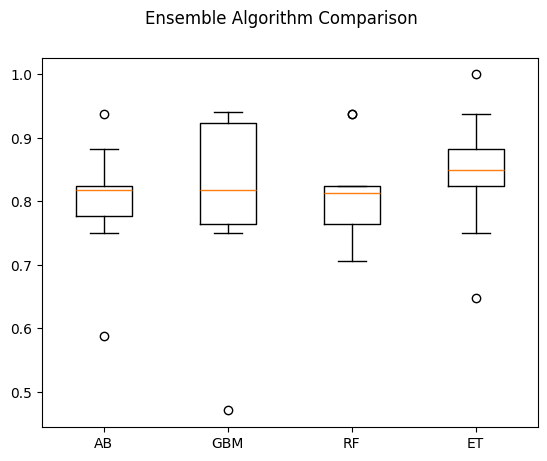

In [ ]:
# Compare Algorithms
fig = pyplot.figure()
fig.suptitle('Ensemble Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

The results suggest two top candidates for further exploration

1. **Gradient Boosting Machine (GBM)**  
   - **Why**: Offers the highest peak performance but suffers from high variance.  
   - **Action**: Tune learning rate, max depth, and apply early stopping to stabilize performance.  
   - **Potential**: With proper tuning, GBM could consistently outperform all others.

2. **Extra Trees (ET)**  
   - **Why**: Strong performance and relatively low variance, indicating robustness.  
   - **Action**: Explore number of trees, feature selection strategies, and max depth.  
   - **Potential**: Might offer the best trade-off between stability and accuracy.

## Finalize Model

The SVM showed the most promise as a low complexity and stable model for this problem. In this section we will finalize the model by training it on the entire training dataset and make predictions for the hold-out validation dataset to confirm our findings. A part of the findings was
that SVM performs better when the dataset is standardized so that all attributes have a mean value of zero and a standard deviation of one. We can calculate this from the entire training dataset and apply the same transform to the input attributes from the validation dataset.

In [ ]:
# prepare the model
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
model = SVC(C=1.7)
model.fit(rescaledX, Y_train)
# estimate accuracy on validation dataset
rescaledValidationX = scaler.transform(X_validation)
predictions = model.predict(rescaledValidationX)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

0.9285714285714286
[[14  1]
 [ 2 25]]
              precision    recall  f1-score   support

         0.0       0.88      0.93      0.90        15
         1.0       0.96      0.93      0.94        27

    accuracy                           0.93        42
   macro avg       0.92      0.93      0.92        42
weighted avg       0.93      0.93      0.93        42



We can see that we achieve an accuracy of nearly 93% on the held-out validation dataset. A score that matches closely to our expectations estimated above during the tuning of SVM.

## Summary

You worked through a classification predictive modeling machine learning problem
from end-to-end using Python. Specifically, the steps covered were:
- Problem Definition (Sonar return data).
- Loading the Dataset.
- Analyze Data (same scale but different distributions of data).
- Evaluate Algorithms (LRD and LNA looked good).
- Evaluate Algorithms with Standardization (KNN and SVM looked good).
- Algorithm Tuning (K=1 for KNN was good, SVM with an RBF kernel and C=1.7 was
best).
- Ensemble Methods (Bagging and Boosting, not quite as good as SVM).
- Finalize Model (use all training data and confirm using validation dataset).

Working through this case study showed you how the recipes for specific machine learning tasks can be pulled together into a complete project. Working through this case study is good practice at applied machine learning using Python.